In [15]:
class MyMath:
    def multiply(a: float,b: float):
        return (a*b)
        
    @staticmethod
    def add(a, b):
        return a + b


In [20]:
m=MyMath()
print(MyMath.__dict__)
print("# keys:",MyMath.__dict__.keys())
print("# values:",MyMath.__dict__.values())
print(m.__dict__)
print(m.add(2, 3))
print(MyMath.add(2, 3))
MyMath.multiply(2, 3)


{'__module__': '__main__', 'multiply': <function MyMath.multiply at 0x0000020BF94472E0>, 'add': <staticmethod(<function MyMath.add at 0x0000020BF9447380>)>, '__dict__': <attribute '__dict__' of 'MyMath' objects>, '__weakref__': <attribute '__weakref__' of 'MyMath' objects>, '__doc__': None}
# keys: dict_keys(['__module__', 'multiply', 'add', '__dict__', '__weakref__', '__doc__'])
# values: dict_values(['__main__', <function MyMath.multiply at 0x0000020BF94472E0>, <staticmethod(<function MyMath.add at 0x0000020BF9447380>)>, <attribute '__dict__' of 'MyMath' objects>, <attribute '__weakref__' of 'MyMath' objects>, None])
{}
5
5


6

In [23]:
class A:
    def f(x):
        print(x)

    @staticmethod
    def g(x):
        print(x)

a = A()

print(A.f)     # function
print(a.f)     # bound method ❗
# print(a.f(2))     # -> python macht: multiply(m, 2, 3), erlaubt 2 parameters, aber 3 parameters:(m, 2, 3) ->  fehler ❗

print(A.g)     # function
print(a.g)     # function


<function A.f at 0x0000020BF9447B00>
<bound method A.f of <__main__.A object at 0x0000020BF954B230>>
<function A.g at 0x0000020BF9447920>
<function A.g at 0x0000020BF9447920>


In [26]:
class A:
    def f(self, x):
        print(x)  # print(a.f(2))  : None, weil kein return definiert ist.

    @staticmethod
    def g(x):
        print(x)

a = A()

print(A.f)     # function
print(a.f)     # bound method ❗
print(A.f(2))  
print(a.f(2))  

<function A.f at 0x0000020BF9995760>
<bound method A.f of <__main__.A object at 0x0000020BF958CBC0>>


TypeError: A.f() missing 1 required positional argument: 'x'

# Intern passiert: class classmethod ist ein Descrptor  -> __get__() kommt in Spiel:
Person.from_upper("ALICE")

-> wird zu Person.from_upper.__func__(Person, "ALICE")

from_upper = classmethod(from_upper)

## Warum funktioniert Person.from_upper() trotzdem?

classmethod.__get__(func, obj, cls)



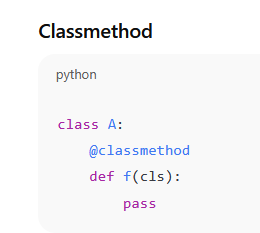

Bei Anlegen von Klass Person wird aufgerufen : func = original funktion:  from_upper gespeichert.

def __init__(self, func):
        self.__func__ = func

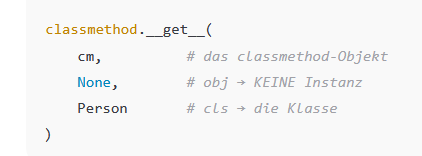

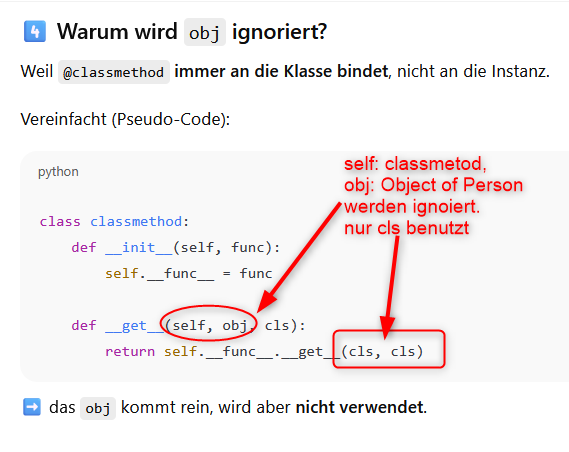


class classmethod:

    def __init__(self, func):
        self.__func__ = func

    def __get__(self, obj, cls):
        return self.__func__.__get__(cls, cls)

__func__= orig. from_upper() funktion, jede Funktion hat ein __get__() und wird zum Laufzeit gerufen.

# from_upper
## "from_upper" wird bei Erzeugung von Klasse "Person" schon als classmethod von python generiert

In [17]:
class Person:
    def __init__(self, name):
        self.name = name

    @classmethod
    def from_upper(cls, name): #cls: 
        return cls(name.lower())
        
# normale Instanz: p
p1= Person("ALICE")
print("1. ", p1.name)
print("2 ",p.__dict__)
print("3 ",Person.__dict__)
print("4 ", Person.__dict__["from_upper"])
print("5 # type:", type(Person.__dict__["from_upper"]))
print("5-1 ", p.from_upper)

print("==============")
p = Person.from_upper("ALICE") # p eine Instanz von Klasse "Person" weil return cls(name.lower()) 
print("6 #p.name:", p.name)
print("7 ", p.from_upper)
print("8 p.__dict__:", p.__dict__)
print("9 ",p.from_upper("ALICE"))



1.  ALICE
2  {'name': 'alice'}
3  {'__module__': '__main__', '__init__': <function Person.__init__ at 0x0000023D56592660>, 'from_upper': <classmethod(<function Person.from_upper at 0x0000023D565934C0>)>, '__dict__': <attribute '__dict__' of 'Person' objects>, '__weakref__': <attribute '__weakref__' of 'Person' objects>, '__doc__': None}
4  <classmethod(<function Person.from_upper at 0x0000023D565934C0>)>
5 # type: <class 'classmethod'>
5-1  <bound method Person.from_upper of <class '__main__.Person'>>
6 #p.name: alice
7  <bound method Person.from_upper of <class '__main__.Person'>>
8 p.__dict__: {'name': 'alice'}
9  <__main__.Person object at 0x0000023D564232F0>


In [20]:
class A:  
    class_attr="Human" #class attribute
    def __init__(self, name, age, speed=10):
           self.name=name
           self.age= age
           self._speed= speed
    def run(self):     #class mathode
        print("running")
    def go(self):       #class mathode
        print("going")
    @property
    def speed(self):       #class mathod
        print("# get intern speed:", self._speed)
        return self._speed

    @speed.setter
    def speed(self, value):       #class method
        self._speed= value
        print("# set intern speed:", self._speed)


In [28]:
a = A("Chen",50)
print("1. ", A.__dict__)
print("2. ", a.run)
print("3. ", a.speed)

1.  {'__module__': '__main__', 'class_attr': 'Human', '__init__': <function A.__init__ at 0x0000023D56AF0CC0>, 'run': <function A.run at 0x0000023D56AF0180>, 'go': <function A.go at 0x0000023D56AF0EA0>, 'speed': <property object at 0x0000023D56B2B510>, '__dict__': <attribute '__dict__' of 'A' objects>, '__weakref__': <attribute '__weakref__' of 'A' objects>, '__doc__': None}
2.  <bound method A.run of <__main__.A object at 0x0000023D5669AB70>>
# get intern speed: 10
3.  10
